In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
import warnings

from util import load_experiment, random_quantiles, random_quantiles_brownian

from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import jensenshannon

In [2]:
warnings.filterwarnings("ignore")

In [14]:
# model_12hr, dataset, config = load_experiment('9e261057-b3c0-4cd9-81ed-d902d1b6b9f7', '../../data/processed/dataset_clean_no-outliers.csv')
# model_12hr_ar, _, _, = load_experiment('ae3cd9a0-d0e6-4118-8a69-44b6ce37fad8', '../../data/processed/dataset_clean_no-outliers.csv', use_autoregressive=True)
# model_24hr_ar, _, _, = load_experiment('f3c623f8-a28d-457c-97af-00ac3cfadd27', '../../data/processed/dataset_clean_no-outliers.csv', use_autoregressive=True)

# model_12hr, dataset, config = load_experiment('647faf84-27a2-4268-82ba-aff0d6f9f039', '../../data/processed/dataset_2018-21_withloads_power.csv', use_autoregressive=True)
# model_24hr, _, _ = load_experiment('9bc9de52-1d8e-49de-91a6-32a467b54265', '../../data/processed/dataset_2018-21_withloads_power.csv', use_autoregressive=True)
# model_168hr, _, _ = load_experiment('2ca44ffe-371f-4648-92f7-3cfcbd5b4f25', '../../data/processed/dataset_2018-21_withloads_power.csv', use_autoregressive=True)

# model_168hr, dataset, config = load_experiment('6b4f6340-3296-4311-86ef-9aaa5c1c34cf', '../probabilistic/wevalidate_data/EIA_930.csv', use_autoregressive=True)
# model_24hr, dataset, config = load_experiment('e6d09ac8-586e-45e5-9313-0789ee8f1cc2', '../probabilistic/wevalidate_data/EIA_930.csv', use_autoregressive=True)
# model_12hr, _, _ = load_experiment('efc364e9-36eb-4d3e-862d-9534ae55c409', '../probabilistic/wevalidate_data/EIA_930.csv', use_autoregressive=True)

model_168hr, dataset, config = load_experiment('f7010b1e-9607-4af8-a6a3-e38c3188663a', '../../data/processed/dataset_14-23.csv', use_autoregressive=True)


Time steps to predict: 24
[3.8355872e-01 4.1789740e-01 1.0692893e-01 0.0000000e+00 4.2826310e-04
 0.0000000e+00 1.6880800e-01 1.5739414e-01 2.6085636e-01 2.8995216e-01
 6.1701167e-02 4.6364391e-01 6.4845389e-01 4.9599874e-01 5.7822591e-01
 7.1738726e-01 7.6511586e-01 4.6472591e-01 7.1184999e-01 7.0704073e-01
 5.9321970e-01 6.0338020e-01 5.5931234e-01 6.2567967e-01]


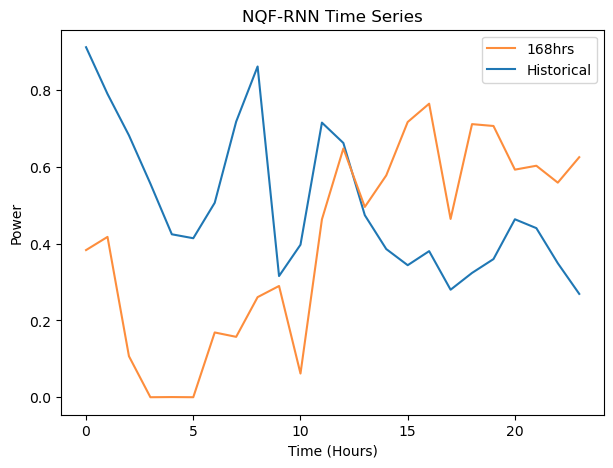

Time steps to predict: 48
[0.4238392  0.30728635 0.17885047 0.19739318 0.19714507 0.06466172
 0.07446481 0.22719237 0.01253908 0.11254409 0.21809399 0.6054898
 0.7125761  0.6205887  0.6394742  0.7075876  0.5046218  0.6427083
 0.67099476 0.5378214  0.6013084  0.6951602  0.47232777 0.31600833
 0.31841496 0.2583896  0.4055711  0.47152308 0.45496804 0.33737755
 0.23684695 0.37555373 0.24488243 0.31248504 0.10923578 0.00152159
 0.05530193 0.0922554  0.         0.00786295 0.04878005 0.
 0.07981621 0.04728879 0.         0.04954535 0.01491105 0.13159709]


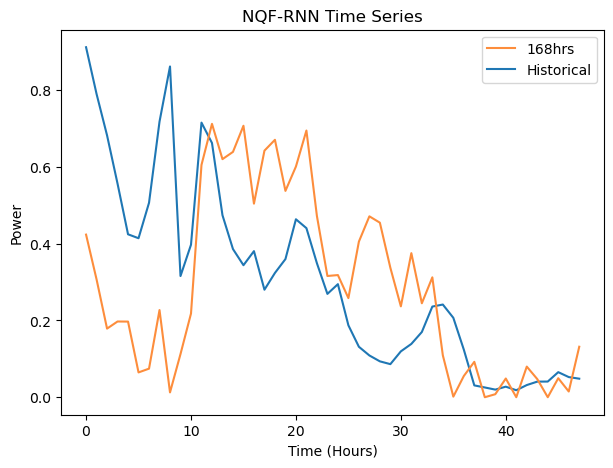

Time steps to predict: 168
[0.44365782 0.47360474 0.2876806  0.11598539 0.         0.02398067
 0.22587088 0.20557836 0.16413917 0.07130592 0.08416715 0.5497417
 0.5931054  0.6858706  0.5520227  0.6281788  0.73285884 0.60458237
 0.76561457 0.6522196  0.59831446 0.4642597  0.49156308 0.5742113
 0.34110183 0.3418612  0.29318932 0.26206806 0.15652755 0.10410041
 0.2345278  0.2875281  0.26433763 0.1414699  0.20054975 0.09000537
 0.         0.1013045  0.19916004 0.1557761  0.16545221 0.
 0.         0.         0.01705658 0.04585593 0.1358486  0.00792801
 0.00520114 0.15168221 0.12709963 0.07568018 0.02421069 0.
 0.02413488 0.02515033 0.254504   0.09309809 0.08310549 0.09783874
 0.22079845 0.2530837  0.0709485  0.         0.22680512 0.
 0.23769802 0.2278452  0.03194097 0.         0.         0.08237949
 0.01258764 0.         0.18052924 0.         0.         0.15817872
 0.18863337 0.09705514 0.2886356  0.1789446  0.26686502 0.3556828
 0.48498094 0.3085238  0.43976527 0.49816743 0.18991438 0.3346

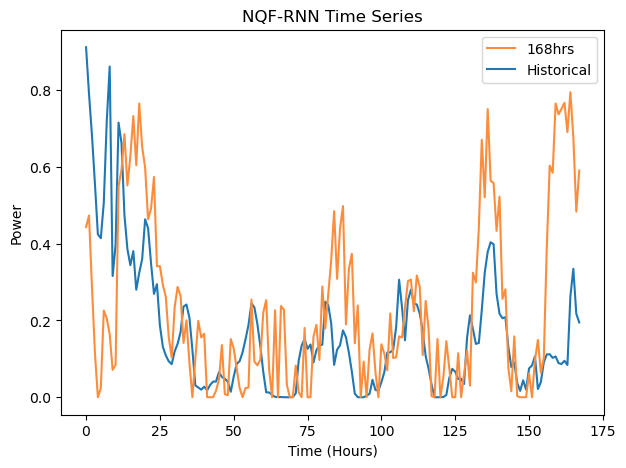

Time steps to predict: 720
[5.91701806e-01 5.24553359e-01 2.68160194e-01 9.73244458e-02
 2.25436375e-01 8.33617151e-02 4.67256457e-02 4.17989120e-02
 3.36031727e-02 1.16764352e-01 0.00000000e+00 4.82081681e-01
 4.63588089e-01 6.51132405e-01 4.18703586e-01 4.71345484e-01
 4.56077605e-01 5.09771228e-01 5.11132598e-01 3.77470613e-01
 3.82680684e-01 2.23294824e-01 3.52323115e-01 4.41933483e-01
 2.25627929e-01 3.96103323e-01 2.82518476e-01 3.71894419e-01
 2.59566188e-01 4.11170036e-01 4.36044335e-01 3.70235860e-01
 2.46312290e-01 1.79330900e-01 2.59353649e-02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.70128453e-03
 0.00000000e+00 1.07725039e-01 3.37032899e-02 1.79257691e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.59206390e-01
 0.00000000e+00 9.82715338e-02 1.45491257e-01 5.66760413e-02
 2.21260823e-03 2.46953636e-01 0.00000000e+00 3.21561694e-01
 9.62989479e-02 1.16506755e-01 1.65133208e-01 2.55644917e-01
 2.32999921e-01 2.92554736e-01 5.58734909e-02 1.82494789e-

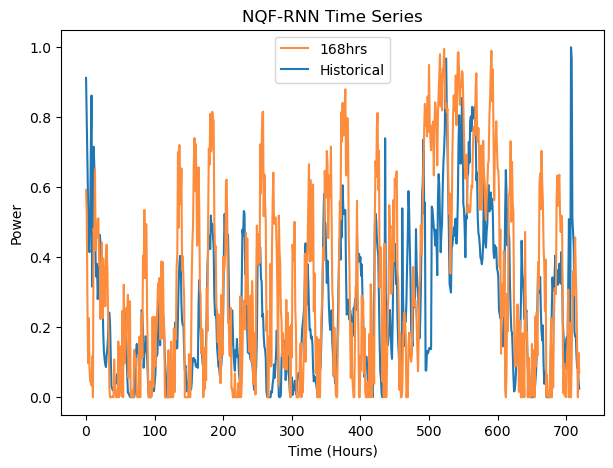

Time steps to predict: 200
[0.34283775 0.56334585 0.05940882 0.24886227 0.16662057 0.
 0.22793618 0.41693178 0.32338998 0.3240803  0.36194572 0.60359246
 0.62610537 0.5394661  0.64332294 0.70846117 0.7414246  0.7211689
 0.6825121  0.6181238  0.63003343 0.6467281  0.5598672  0.5460549
 0.37891245 0.50279444 0.33001643 0.4758485  0.24440777 0.09211423
 0.41364127 0.1057045  0.33053738 0.36599833 0.06322916 0.06135369
 0.02730462 0.14189592 0.07246295 0.         0.         0.11303809
 0.12137467 0.         0.         0.         0.         0.12235363
 0.14561258 0.17206642 0.21699242 0.09466894 0.         0.07027763
 0.         0.04350885 0.18532813 0.32344064 0.39782065 0.29459056
 0.46093363 0.1215907  0.13136292 0.05511801 0.05580882 0.10904533
 0.23941267 0.13828777 0.18478179 0.00178684 0.07382966 0.
 0.21129853 0.03907332 0.30472887 0.31502467 0.28671214 0.15696129
 0.03808656 0.30228016 0.22778836 0.10471265 0.2511077  0.474115
 0.3439334  0.26063722 0.19990268 0.40474975 0.28698725

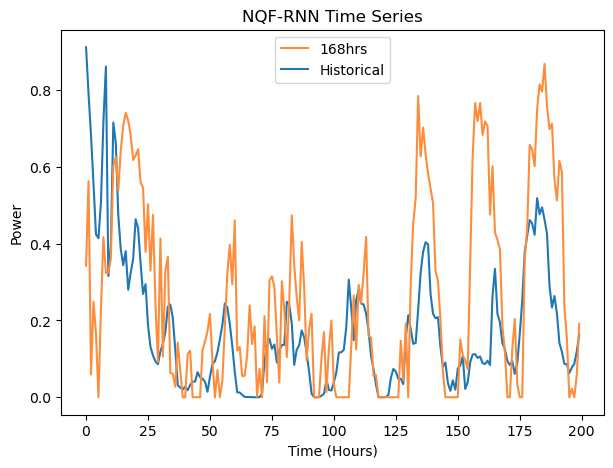

In [15]:
(speed, power) = dataset

# models = [model_12hr, 
#           model_24hr, 
#           model_48hr, 
#           model_72hr, 
#           model_96hr, 
#           model_120hr, 
#           model_144hr,
#           model_168hr]
# model_labels = [12, 24, 48, 72, 96, 120, 144, 168]

# models = [model_12hr, model_24hr, model_168hr]
# model_labels = ['12hrs', '24hrs', '168hrs']
models = [model_168hr]
model_labels = ['168hrs']

# scales = ['1 day', '2 days', '1 week', '1 month']
scales = ['1 day', '2 days', '1 week', '1 month', '200 hours']
upper_bounds = [24, 24 * 2, 24 * 7, 24 * 30, 200]

M = len(models)

for i in range(len(scales)):
    scale = scales[i]
    T = upper_bounds[i]
    x = np.arange(0, T)

    input = speed[:T].unsqueeze(0)
    target = power[:T]

    norm_speed = input.squeeze() / torch.max(input)
    cmap = plt.get_cmap('YlOrRd', M + 2)
    print(f'Time steps to predict: {T}')
    # Use same quantiles for all models to ensure "fairness" in visualizing predictions

    plt.figure(figsize=(7, 5))

    quantiles = random_quantiles(size=(T), low=0.01, high=0.99)
    for j in range(M):
        model = models[j]
        label = model_labels[j]
        predicted_power = model(input, quantiles).detach().cpu().numpy().squeeze()
        print(predicted_power)
        plt.plot(x, predicted_power, label=f'{label}', color=cmap(j+1))

    plt.plot(x, target, label='Historical', color='tab:blue', zorder=0)
    # plt.plot(x, norm_speed, '--b', label='Wind Speeds (Normalized)')

    plt.title(f'NQF-RNN Time Series')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Power')
    plt.legend()
    plt.show()

[]

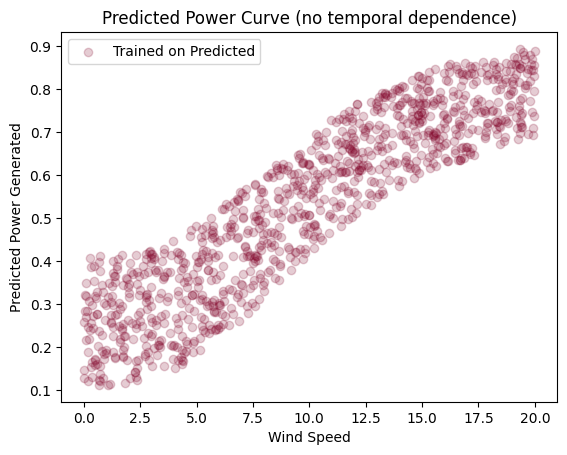

In [5]:
N = 1000
random_wind_speeds = np.random.uniform(0, 20, N)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    preds = []
    cmap = plt.get_cmap('YlOrRd', M + 2)

    for speed in random_wind_speeds:
        input = torch.tensor([speed], dtype=torch.float).unsqueeze(0)
        alpha = random_quantiles(1, 0.01, 0.99)
        pred = model(input, alpha).detach().cpu().numpy().squeeze()
        preds.append(pred)
    plt.scatter(random_wind_speeds, preds, alpha=0.2, color=cmap(i+2), label=f'Trained on {label}')
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (no temporal dependence)')
plt.legend()
plt.plot()

[]

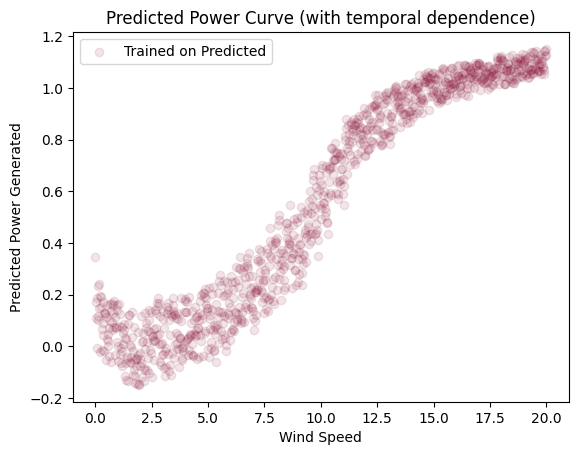

In [6]:
N = 1000
random_wind_speeds = np.linspace(0, 20, N)
cmap = plt.get_cmap('YlOrRd', M + 2)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    input = torch.tensor(random_wind_speeds, dtype=torch.float).unsqueeze(0)
    alpha = random_quantiles(N, 0.01, 0.99)
    preds = model(input, alpha).detach().cpu().numpy().squeeze()
    plt.scatter(random_wind_speeds, preds, alpha=0.1, color=cmap(i+2), label=f"Trained on {label}")
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (with temporal dependence)')
plt.legend()
plt.plot()

[]

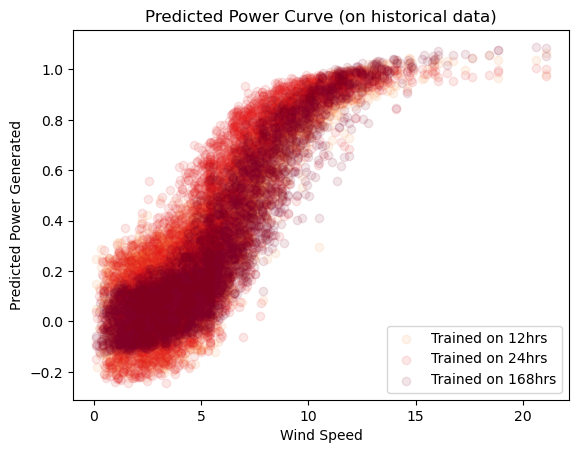

In [11]:
cmap = plt.get_cmap('YlOrRd', M + 2)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
    alpha = random_quantiles(len(speed), 0.01, 0.99)
    preds = model(input, alpha).detach().cpu().numpy().squeeze()
    plt.scatter(speed, preds, alpha=0.1, color=cmap(i+2), label=f"Trained on {label}")
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (on historical data)')
plt.legend()
plt.plot()

[]

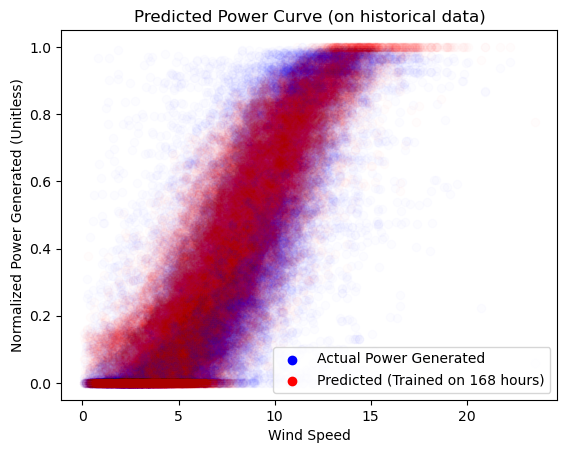

In [24]:
from matplotlib.collections import PathCollection
from matplotlib.legend_handler import HandlerPathCollection, HandlerLine2D

cmap = plt.get_cmap('YlOrRd', M + 2)

model = model_168hr
input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
alpha = random_quantiles(len(speed), 0.01, 0.99)
preds = model(input, alpha).detach().cpu().numpy().squeeze()

plt.scatter(speed, power, alpha=0.01, color='b', label=f"Actual Power Generated")
plt.scatter(speed, preds, alpha=0.01, color='r', label=f"Predicted (Trained on 168 hours)")
plt.ylabel('Normalized Power Generated (Unitless)')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (on historical data)')

def update(handle, orig):
    handle.update_from(orig)
    handle.set_alpha(1)

plt.legend(handler_map={PathCollection : HandlerPathCollection(update_func= update),
                        plt.Line2D : HandlerLine2D(update_func = update)})
plt.plot()

## presentation graphs

In [16]:
# df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'lmp', 'user_load_zonal'])
# df.rename({'speed_HRRR': 'speed', 'ercot_power': 'power'}, axis=1, inplace=True)
# # normalize power and speed
# df['npower'] = df['power'] / df['power'].max()
# df['nspeed'] = (df['speed'] - df['speed'].min()) / (df['speed'].max() - df['speed'].min())


# df = pd.read_csv('../probabilistic/wevalidate_data/EIA_930.csv')
df = pd.read_csv('../../data/processed/dataset_14-23.csv')
df['npower'] = df['power'] / df['power'].max()

In [17]:
model = model_168hr # model_12hr, model_24hr, model_168hr
input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
# alpha = random_quantiles(len(speed), 0.01, 0.99)
alpha = random_quantiles_brownian(len(speed), 0.01, 0.99, smoothing=0.01, drift=0.005)
npreds = model(input, alpha).detach().cpu().numpy().squeeze()
preds = npreds * 244.5
# preds = npreds * 104.4

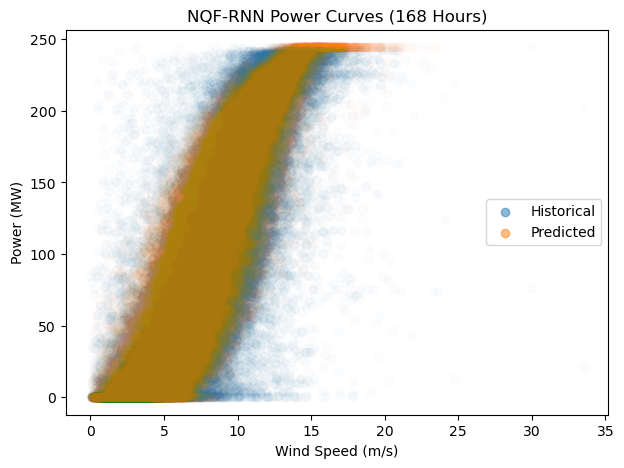

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(df['speed'], df['power'], alpha=0.015, label='Historical')
plt.scatter(df['speed'], preds, alpha=0.01, label='Predicted')
# plt.scatter(df['speed'], df['power'], alpha=0.1, label='Historical')
# plt.scatter(df['speed'], preds, alpha=0.1, label='Predicted')

plt.ylabel('Power (MW)')
plt.xlabel('Wind Speed (m/s)')
plt.title('NQF-RNN Power Curves (168 Hours)')

leg = plt.legend()
for leg in leg.legend_handles:
    leg.set_alpha(0.5)

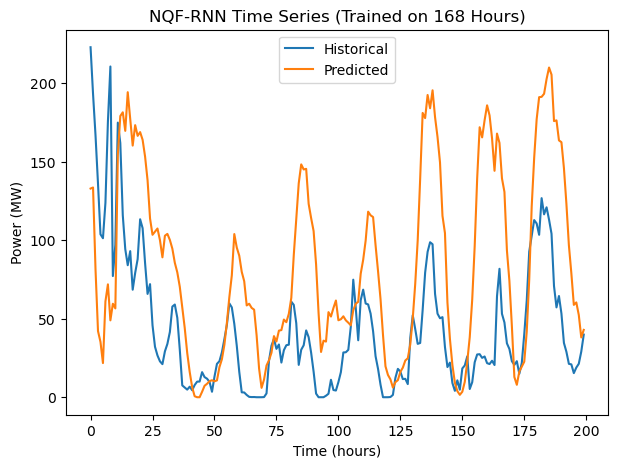

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(df['power'][:200], label='Historical')
plt.plot(preds[:200], label='Predicted')
plt.title('NQF-RNN Time Series (Trained on 168 Hours)')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

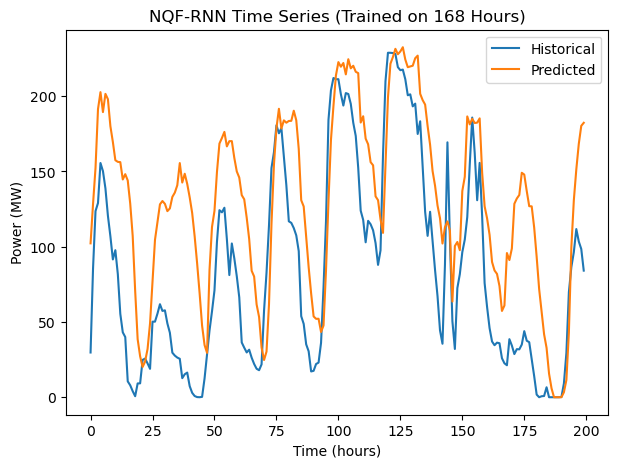

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(df['power'][2000:2200].reset_index(drop=True), label='Historical')
plt.plot(preds[2000:2200], label='Predicted')
plt.title('NQF-RNN Time Series (Trained on 168 Hours)')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

In [21]:
import sys
sys.path.append('../evaluation')
from evaluation import Metrics, Plot

RNN 168hr Metrics:
RMSE: 0.21990144142294665
Bias: 0.055352762019485656
Cross Correlation: 0.7648585381155232
Similarity: 0.7958210651545885
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 127.96834564208984


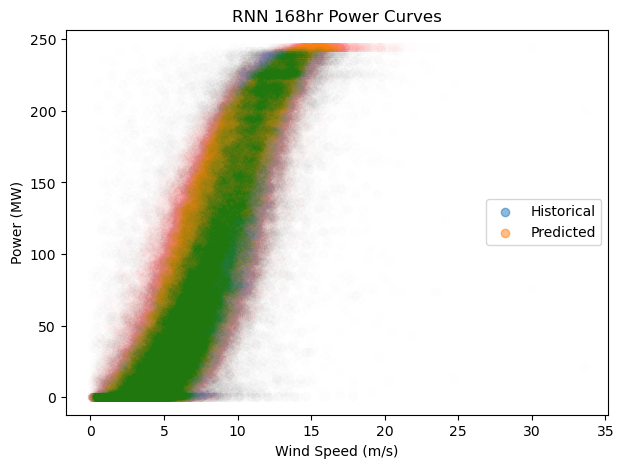

AttributeError: 'numpy.ndarray' object has no attribute 'reset_index'

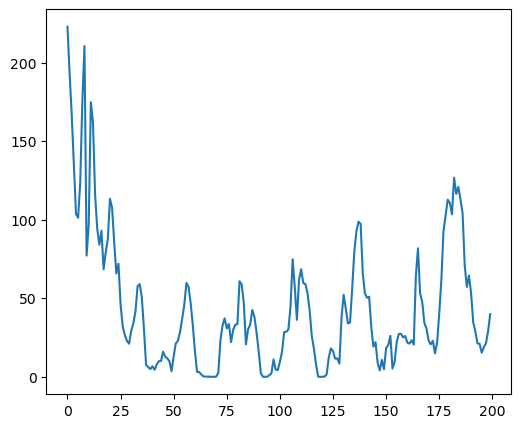

In [22]:
rnn_metrics = Metrics('RNN 168hr', df['speed'], df['power'], preds)
rnn_plot = Plot('RNN 168hr', df['speed'], df['power'], preds)
rnn_metrics.print_metrics()
rnn_plot.plot_all()

In [26]:
print(mean_squared_error(df['npower'], npreds))
print(np.sqrt(mean_squared_error(df['npower'], npreds)))

0.06638729117711073
0.25765731345550963


In [ ]:
df['preds'] = preds

In [35]:
df.to_csv('../probabilistic/new_results/rnn_1423_brownian.csv', index=False)

### comparing power curves

In [14]:
H_true, _, _ = np.histogram2d(df['speed'], df['power'], bins=50)
H_pred, _, _ = np.histogram2d(df['speed'], preds, bins=50)

# normalize
H_true_norm = H_true / H_true.sum()
H_pred_norm = H_pred / H_pred.sum()

mse = np.mean((H_true_norm - H_pred_norm) ** 2)
js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())  # Value between 0 and 1
similarity = 1 - js_div
match_percentage = np.round((1 - js_div) * 100, 2)

In [15]:
print(f"MSE: {mse}")
print(f"JS Divergence: {js_div}")
print(f"Similarity: {similarity}")
print(f"Match Percentage: {match_percentage}%")

MSE: 2.000209647010537e-07
JS Divergence: 0.20615440292028453
Similarity: 0.7938455970797155
Match Percentage: 79.38%


Text(0.5, 0.98, 'NQF-RNN 168hrs (Match: 79.38%)')

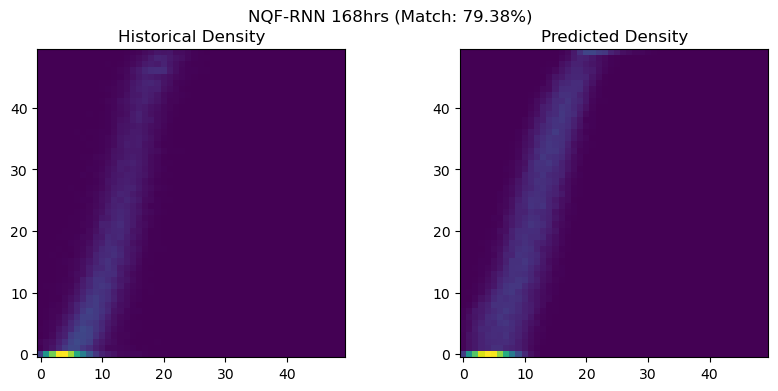

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(H_true_norm.T, origin='lower')
axs[0].set_title("Historical Density")

axs[1].imshow(H_pred_norm.T, origin='lower')
axs[1].set_title("Predicted Density")

fig.suptitle(f"NQF-RNN 168hrs (Match: {match_percentage}%)")

In [22]:
def compute_similarity(true_power, pred_power):
    H_true, _, _ = np.histogram2d(df['speed'], true_power, bins=50)
    H_pred, _, _ = np.histogram2d(df['speed'], pred_power, bins=50)

    # normalize
    H_true_norm = H_true / H_true.sum()
    H_pred_norm = H_pred / H_pred.sum()

    js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())
    similarity = 1 - js_div

    return similarity, H_true_norm, H_pred_norm

In [23]:
# predictions for each model
input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
alpha = random_quantiles(len(speed), 0.01, 0.99)

npreds_12hr = model_12hr(input, alpha).detach().cpu().numpy().squeeze()
npreds_24hr = model_24hr(input, alpha).detach().cpu().numpy().squeeze()
npreds_168hr = model_168hr(input, alpha).detach().cpu().numpy().squeeze()

# preds_12hr = preds_12hr * 244.5
# preds_24hr = preds_24hr * 244.5
# preds_168hr = preds_168hr * 244.5

preds_12hr = npreds_12hr * 104.4
preds_24hr = npreds_24hr * 104.4
preds_168hr = npreds_168hr * 104.4

Similarity (12 hr model): 0.672082325821546
Similarity (24 hr model): 0.6708187860139949
Similarity (168 hr model): 0.6734708595581833


Text(0.5, 1.0, 'Predicted Density (168 hr)')

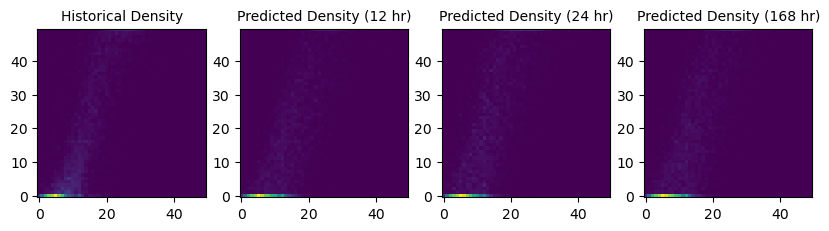

In [24]:
# compute similarity for each model
similarity_12hr, H_true_12hr, H_pred_12hr = compute_similarity(df['power'], preds_12hr)
similarity_24hr, H_true_24hr, H_pred_24hr = compute_similarity(df['power'], preds_24hr)
similarity_168hr, H_true_168hr, H_pred_168hr = compute_similarity(df['power'], preds_168hr)

print(f"Similarity (12 hr model): {similarity_12hr}")
print(f"Similarity (24 hr model): {similarity_24hr}")
print(f"Similarity (168 hr model): {similarity_168hr}")


# plot densities
fig, axs = plt.subplots(1, 4, figsize=(10, 4))
axs[0].imshow(H_true_12hr.T, origin='lower')
axs[0].set_title("Historical Density", fontsize=10)

axs[1].imshow(H_pred_12hr.T, origin='lower')
axs[1].set_title("Predicted Density (12 hr)", fontsize=10)

axs[2].imshow(H_pred_24hr.T, origin='lower')
axs[2].set_title("Predicted Density (24 hr)", fontsize=10)

axs[3].imshow(H_pred_168hr.T, origin='lower')
axs[3].set_title("Predicted Density (168 hr)", fontsize=10)


## save csv for we-validate

In [28]:
from datetime import datetime, timedelta

In [30]:
df['preds'] = preds
df['npreds'] = npreds

# df['npreds_12hr'] = npreds_12hr
# df['npreds_24hr'] = npreds_24hr
# df['npreds_168hr'] = npreds_168hr

# df['preds_12hr'] = preds_12hr
# df['preds_24hr'] = preds_24hr
# df['preds_168hr'] = preds_168hr

In [31]:
df

,datetime,speed,power,npower,preds,npreds
0,2014-07-30 12:00:00,9.416307,222.814,0.912316,125.620758,0.513786
1,2014-07-30 13:00:00,8.168459,193.077,0.790557,100.206474,0.409842
2,2014-07-30 14:00:00,6.081183,166.707,0.682585,57.116852,0.233607
3,2014-07-30 15:00:00,3.644644,135.965,0.556711,27.820589,0.113786
4,2014-07-30 16:00:00,4.062179,103.724,0.424700,0.000000,0.000000
...,...,...,...,...,...,...
82295,2023-12-31 19:00:00,10.002887,14.636,0.059927,114.404427,0.467912
82296,2023-12-31 20:00:00,9.850973,5.243,0.021468,93.983803,0.384392
82297,2023-12-31 21:00:00,9.078698,0.446,0.001826,74.867714,0.306207
82298,2023-12-31 22:00:00,8.771991,0.195,0.000798,136.012924,0.556290


In [32]:
df.rename(columns={'datetime': 'time_stamp'}, inplace=True)

In [33]:
# generate time_stamps in order for we-validate compatibility
def generate_time_stamps(start_date):
    current = start_date
    time_stamps = []
    while len(time_stamps) < 82300:
        time_stamps.append(current.strftime('%Y-%m-%d %H:%M:%S'))
        current += timedelta(hours=1)
    return time_stamps

time_stamp = generate_time_stamps(datetime(2014, 7, 30, 12, 0, 0))
df['time_stamp'] = time_stamp

In [34]:
df

,time_stamp,speed,power,npower,preds,npreds
0,2014-07-30 12:00:00,9.416307,222.814,0.912316,125.620758,0.513786
1,2014-07-30 13:00:00,8.168459,193.077,0.790557,100.206474,0.409842
2,2014-07-30 14:00:00,6.081183,166.707,0.682585,57.116852,0.233607
3,2014-07-30 15:00:00,3.644644,135.965,0.556711,27.820589,0.113786
4,2014-07-30 16:00:00,4.062179,103.724,0.424700,0.000000,0.000000
...,...,...,...,...,...,...
82295,2023-12-19 11:00:00,10.002887,14.636,0.059927,114.404427,0.467912
82296,2023-12-19 12:00:00,9.850973,5.243,0.021468,93.983803,0.384392
82297,2023-12-19 13:00:00,9.078698,0.446,0.001826,74.867714,0.306207
82298,2023-12-19 14:00:00,8.771991,0.195,0.000798,136.012924,0.556290


In [35]:
df.to_csv('../probabilistic/results/rnn_168hr_1423.csv', index=False)